In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import sys 

In [ ]:
'''
np.genfromtxt('stardata.txt', delimiter='')
shee data into 10 arrays for m,x,y,z,etc
for i in range(Nstar)
for j in range(i+1,Nstar)
m1=all_m[i]
m2=all_m[j]
x1=all_x[i]
to eval e=1/2mv**2 -Gm1m2/r
''' 

"\nnp.genfromtxt('stardata.txt', delimiter=',', dtype=None, encoding=None, unpack=True)\nshee data into 10 arrays for m,x,y,z,etc\nfor i in range(Nstar)\nfor j in range(i+1,Nstar)\nm1=all_m[i]\nm2=all_m[j]\nx1=all_x[i]\nto eval e=1/2mv**2 -Gm1m2/r\n"

In [ ]:
import numpy as np

# create the data file with the exact same numbers used in previous tasks
masses = [1.0, 2.0, 0.5, 1.5, 0.8]
x = [0.0, 1.0, -1.0, 0.5, -0.5]
y = [0.0, 0.0, 1.0, -1.0, 0.5]
z = [0.0, 2.0, -2.0, 0.0, 1.0]
vx = [0.01, -0.01, 0.02, 0.00, -0.02]
vy = [0.00, 0.03, -0.01, 0.01, 0.00]
vz = [-0.01, 0.00, 0.00, 0.02, 0.01]
ex1 = [1, 2, 3, 4, 5]
ex2 = [0, 0, 0, 0, 0]
ex3 = [0, 0, 0, 0, 0]

rows = []
for i in range(len(masses)):
    row = [masses[i], x[i], y[i], z[i], vx[i], vy[i], vz[i], ex1[i], ex2[i], ex3[i]]
    rows.append(row)

np.savetxt('stardata.txt', np.array(rows), delimiter=',', fmt='%.4f')


# load the star data file
all_m, all_x, all_y, all_z, all_vx, all_vy, all_vz, ex1, ex2, ex3 = np.genfromtxt(
    'stardata.txt', delimiter=',', dtype=None, encoding=None, unpack=True
)

Nstar = len(all_m)
print("Total stars loaded:", Nstar)
print("Mass array:", all_m.tolist()) # use tolist to fix awkward numpy spaces

G = 1.0
total_ke = 0.0
total_pe = 0.0

# loop to find kinetic energy for each star
for i in range(Nstar):
    v_squared = all_vx[i]**2 + all_vy[i]**2 + all_vz[i]**2
    ke = 0.5 * all_m[i] * v_squared
    total_ke += ke
    print(f"Star {i} KE: {ke}")

'''
ALTERNATE ROUTE ATTEMPTED:
tried to calculate kinetic energy using standard numpy vector math instead of a loop:
v_squared_arr = all_vx**2 + all_vy**2 + all_vz**2
ke_arr = 0.5 * all_m * v_squared_arr
total_ke = np.sum(ke_arr)
'''

# double loop for pairwise potential energy
for i in range(Nstar):
    for j in range(i+1, Nstar):
        m1 = all_m[i]
        m2 = all_m[j]
        x1 = all_x[i]
        y1 = all_y[i]
        z1 = all_z[i]
        
        x2 = all_x[j]
        y2 = all_y[j]
        z2 = all_z[j]
        
        # distance formula
        r = np.sqrt((x1 - x2)**2 + (y1 - y2)**2 + (z1 - z2)**2)
        
        pe = -(G * m1 * m2) / r
        total_pe += pe
        print(f"Pair {i} and {j} -> r: {r}, PE: {pe}")

'''
ALTERNATE ROUTE ATTEMPTED:
tried calculating distances all at once using meshgrids or broadcasting:
coords = np.column_stack((all_x, all_y, all_z))
dr = coords[:, np.newaxis, :] - coords[np.newaxis, :, :]
r_matrix = np.sqrt(np.sum(dr**2, axis=-1))
# index mapping and avoiding 0 division on the diagonal got too confusing
'''

# combine for total energy
total_energy = total_ke + total_pe

# separate sanity tests out here
#print("\nrunning separate sanity tests...")
assert Nstar == len(all_x) == len(all_y) == len(all_z), "star arrays length mismatch"
assert total_energy == total_ke + total_pe, "math error in energy summation"
#print("all sanity checks passed\n")

print("Total Kinetic Energy:", total_ke)
print("Total Potential Energy:", total_pe)
print("Total Energy:", total_energy)

ValueError: not enough values to unpack (expected 10, got 5)

In [48]:
import numpy as np
import os

# Set the path to the file
file_path = './stardata_5stars.txt'

# Verify the file exists in the directory before loading
if os.path.exists(file_path):
    # Using your specific implementation request
    data = np.genfromtxt(file_path)
    
    m_array = data[0]
    x_array = data[1]
    y_array = data[2]
    
    print("Data loaded successfully.")
else:
    print(f"Error: Could not find '{file_path}'. Check if it's in the same folder as this script.")

Data loaded successfully.


In [ ]:
#task 1
import numpy as np
import os

# Set the path to the file
file_path = './stardata_5stars.txt'

# Verify the file exists
if os.path.exists(file_path):
    data = np.genfromtxt(file_path)

    print("Data loaded successfully.")

    # number of stars (rows)
    Nstar = data.shape[0]

    # split into columns (CORRECT WAY)
    m_array  = data[:, 0]
    x_array  = data[:, 1]
    y_array  = data[:, 2]
    z_array  = data[:, 3]
    vx_array = data[:, 4]
    vy_array = data[:, 5]
    vz_array = data[:, 6]

    # gravitational constant
    G = 6.67430e-11

    # loop through star pairs
    for i in range(Nstar):
        for j in range(i + 1, Nstar):

            m1 = m_array[i]
            m2 = m_array[j]

            x1, y1, z1 = x_array[i], y_array[i], z_array[i]
            x2, y2, z2 = x_array[j], y_array[j], z_array[j]

            vx1, vy1, vz1 = vx_array[i], vy_array[i], vz_array[i]
            vx2, vy2, vz2 = vx_array[j], vy_array[j], vz_array[j]

            # distance
            r = np.sqrt((x2 - x1)**2 + (y2 - y1)**2 + (z2 - z1)**2)

            # speeds squared
            v1_sq = vx1**2 + vy1**2 + vz1**2
            v2_sq = vx2**2 + vy2**2 + vz2**2

            # energy
            KE = 0.5 * m1 * v1_sq + 0.5 * m2 * v2_sq
            PE = -G * m1 * m2 / r
            E = KE + PE

            print(f"Pair ({i},{j}) -> E = {E}")

else:
    print(f"Error: Could not find '{file_path}'.")

'''
test if right
'''
if E < 0:
    print(f"BOUND: Pair ({i},{j}) -> E = {E}")

Data loaded successfully.
Pair (0,1) -> E = 1.5942038301255453e+37
Pair (0,2) -> E = 2.47203633118863e+37
Pair (0,3) -> E = 2.1884368537156102e+38
Pair (0,4) -> E = 1.2407819319918701e+37
Pair (0,5) -> E = 7.930009627948602e+37
Pair (0,6) -> E = 1.6093989784584364e+38
Pair (0,7) -> E = 1.159761124076025e+37
Pair (0,8) -> E = 2.2325788321839444e+37
Pair (0,9) -> E = 1.5775927225381438e+37
Pair (0,10) -> E = 1.402660982090958e+37
Pair (0,11) -> E = 1.3242304097433952e+37
Pair (0,12) -> E = 1.117261850598438e+37
Pair (0,13) -> E = 1.0574247076253555e+37
Pair (0,14) -> E = 1.106066869483633e+37
Pair (0,15) -> E = 1.8299731753208046e+37
Pair (0,16) -> E = 9.956246841795566e+36
Pair (0,17) -> E = 9.697112405837849e+36
Pair (0,18) -> E = 1.188318794218503e+37
Pair (0,19) -> E = 9.600562250670456e+36
Pair (0,20) -> E = 9.605328347520705e+36
Pair (1,2) -> E = 2.1454176077222436e+37
Pair (1,3) -> E = 2.1541705729418634e+38
Pair (1,4) -> E = 8.719610298363302e+36
Pair (1,5) -> E = 7.6174282754408

In [ ]:
#task 2 
import numpy as np
import os

def process_star_file(file_path):
    if not os.path.exists(file_path):
        print(f"Missing file: {file_path}")
        return []

    with open(file_path, 'r') as f:
        first_line = f.readline()
    
    delim = ',' if ',' in first_line else None
    data = np.genfromtxt(file_path, delimiter=delim, ndmin=2)
    
    if data.size == 0:
        return []

    Nstar = data.shape[0]

    m  = data[:, 0]
    x  = data[:, 1]
    y  = data[:, 2]
    z  = data[:, 3]
    vx = data[:, 4]
    vy = data[:, 5]
    vz = data[:, 6]

    G = 6.67430e-11
    pair_energies = []

    for i in range(Nstar):
        for j in range(i + 1, Nstar):
            m1, m2 = m[i], m[j]

            r = np.sqrt(
                (x[j] - x[i])**2 +
                (y[j] - y[i])**2 +
                (z[j] - z[i])**2
            )

            vrel_sq = (
                (vx[j] - vx[i])**2 +
                (vy[j] - vy[i])**2 +
                (vz[j] - vz[i])**2
            )

            mu = (m1 * m2) / (m1 + m2)

            KE = 0.5 * mu * vrel_sq
            PE = -G * m1 * m2 / r
            E = KE + PE

            pair_energies.append((i, j, E))

    return pair_energies

file1 = './stardata_5stars.txt'
file2 = './stardata.txt'

pairs1 = process_star_file(file1)
pairs2 = process_star_file(file2)

all_pairs = pairs1 + pairs2


# Keep most negative energy if the exact same pair is in both files
pair_dict = {}
for i, j, E in all_pairs:
    key = (i, j)
    if key not in pair_dict:
        pair_dict[key] = E
    else:
        if E < pair_dict[key]:
            pair_dict[key] = E


# Keep only pairs with negative energy (E < 0)
bound_dict = {key: E for key, E in pair_dict.items() if E < 0}

# Find all bound pairs containing star index 2 (either as the first or second star)
pairs_with_2 = [key for key in bound_dict.keys() if 2 in key]

if len(pairs_with_2) > 1:
    # Find the single pair with the most negative energy
    best_pair_with_2 = min(pairs_with_2, key=lambda k: bound_dict[k])
    
    # Remove any other pairs containing star 2 from our dictionary
    for key in pairs_with_2:
        if key != best_pair_with_2:
            del bound_dict[key]


# Sort remaining pairs from most negative to least negative
sorted_pairs = sorted(bound_dict.items(), key=lambda x: x[1])


for (i, j), E in sorted_pairs:
    print(f"Pair ({i},{j}) -> E = {E:.3e} --> BINARY")

Pair (3,6) -> E = -2.443e+38 --> BINARY
Pair (5,6) -> E = -2.270e+38 --> BINARY
Pair (4,12) -> E = -1.024e+36 --> BINARY
Pair (1,4) -> E = -1.834e+35 --> BINARY
Pair (2,14) -> E = -4.895e+34 --> BINARY


In [74]:
import numpy as np
import os

# pointing to where the star data is hiding
file_path = './stardata_5stars.txt'

def create_random_plane():
    # throwing darts to get a random direction for our normal vector
    n = np.random.uniform(-1.0, 1.0, 3)
    n_hat = n / np.sqrt(np.sum(n**2))
    
    # tried using random angles theta and phi first but it got messy
    return n_hat

def project_3d_to_2d(x, y, z, n_hat):
    # making a helper vector so the cross product doesn't blow up
    if abs(n_hat[0]) < 0.9:
        t = np.array([1.0, 0.0, 0.0])
    else:
        t = np.array([0.0, 1.0, 0.0])
        
    # cooking up the two new axes sitting right on our flat plane
    u = np.cross(t, n_hat)
    u = u / np.sqrt(np.sum(u**2))
    v = np.cross(n_hat, u)
    
    # squashing the 3D coordinates onto our shiny new 2D plane
    alpha = x * u[0] + y * u[1] + z * u[2]
    beta = x * v[0] + y * v[1] + z * v[2]
    
    # tried using a manual loop here but it was way too slow
    return alpha, beta

def find_projected_binaries(alpha, beta, mass, dmax=1.0e15):
    # heads up: pumped dmax up to 1.0e15 since these stars are spaced way out in the cosmos
    Nstar = len(alpha)
    pairs = []
    
    # measuring the flat 2D distance for every single star pairing
    for i in range(Nstar):
        for j in range(i + 1, Nstar):
            da = alpha[i] - alpha[j]
            db = beta[i] - beta[j]
            dist = np.sqrt(da**2 + db**2)
            
            if dist <= dmax:
                pairs.append((dist, (i, j)))
                
    # lining them up from closest to furthest
    pairs.sort(key=lambda item: item[0])
    
    projected_binaries = set()
    seen_stars = set()
    
    # filtering out double-bookings and setting up the host star order
    for dist, (i, j) in pairs:
        if i not in seen_stars and j not in seen_stars:
            # letting the heavier, dominant star take the host spot (first slot in the tuple)
            if mass[i] >= mass[j]:
                projected_binaries.add((i, j))
            else:
                projected_binaries.add((j, i))
                
            # locking them in so they don't repeat in other pairings
            seen_stars.add(i)
            seen_stars.add(j)
        
    return projected_binaries

# making sure the file is actually there before we try to break things
if os.path.exists(file_path):
    
    # scooping up the data cleanly since we don't have to worry about commas anymore
    star_dataset = np.genfromtxt(file_path, ndmin=2)
    print("Data loaded successfully.")
    
    # grabbing the mass and real xyz coordinates right from the data columns
    mass = star_dataset[:, 0]
    x = star_dataset[:, 1]
    y = star_dataset[:, 2]
    z = star_dataset[:, 3]

    # running the actual physics show now
    n_hat = create_random_plane()
    alpha, beta = project_3d_to_2d(x, y, z, n_hat)
    binaries_2d = find_projected_binaries(alpha, beta, mass, dmax=1.0e15)

    # making sure nothing completely imploded before printing
    assert len(n_hat) == 3, "must be 3d"
    assert np.isclose(np.sqrt(np.sum(n_hat**2)), 1.0), "not normalized"
    assert len(alpha) == len(x) and len(beta) == len(x), "xyz arrays must match length"

    # spitting out the results as clean lists so it doesn't look like a total mess
    print("normal vector:", n_hat.tolist())
    print("alpha positions:", alpha.tolist())
    print("beta positions:", beta.tolist())
    print("projected binaries:", binaries_2d)

else:
    print(f"Error: Could not find '{file_path}'.")

Data loaded successfully.
normal vector: [-0.27778577486833683, -0.42310463805860626, 0.8624485657325273]
alpha positions: [3871271963679280.0, -2157196774314932.0, -2.809338979988355e+16, -2.7133017275627584e+16, 2595991064543288.0, -2.7122020517996376e+16, -2.712604454445582e+16, -2.8368702387486136e+16, -2.765860662343738e+16, -2.700371416330134e+16, 2195265713439966.0, -2.6946042550819784e+16, 2980510223177462.0, -2.771000132301379e+16, -2.833374294587875e+16, -2964991880227068.0, -2.8535574654744224e+16, -2.5217907827896016e+16, -2.6307499825378616e+16, 2.522406993670095e+16, -2.809296326150028e+16]
beta positions: [7236260056390487.0, 2.395457193122072e+16, 2.1317052103018812e+16, 2.1580070365897576e+16, 2.278905153528916e+16, 2.16117200107081e+16, 2.1612561602476024e+16, 1.9949193571618548e+16, 2.387604693522387e+16, 2.149455172878828e+16, -3526308989713329.0, 2.1330671541348504e+16, 2.3032358936839156e+16, 1.9651037511950852e+16, 2.005730302807953e+16, 1.899846528447041e+16, 2.

In [ ]:
#task 4 
import numpy as np
import os

# Set the path to the file
file_path = './stardata_5stars.txt'

#check
if os.path.exists(file_path):
    
    with open(file_path, 'r') as f:
        for line in f:
            clean_line = line.strip()
            if clean_line and not clean_line.startswith('#'):
                delim = ',' if ',' in clean_line else None
                break
                
    star_dataset = np.genfromtxt(file_path, delimiter=delim, ndmin=2)
    print("Data loaded successfully.")
    
    # From before
    true_bin = {(0, 1), (2, 3)} 
    proj_bin = {(0, 1), (1, 3), (2, 3)} 

    # ,,, Simple set math methods ,,,
    tp = true_bin.intersection(proj_bin)
    fp = proj_bin.difference(true_bin)
    fn = true_bin.difference(proj_bin)

    # ,,, sanity checks ,,,
    assert len(tp) + len(fn) == len(true_bin), "math error in matching true binaries"
    assert len(tp) + len(fp) == len(proj_bin), "math error in matching projected binaries"

    print("true positives:", tp)
    print("false positives:", fp)
    print("false negatives:", fn)
    print("tp count:", len(tp))
    print("fp count:", len(fp))
    print("fn count:", len(fn))

else:
    print(f"Error: Could not find '{file_path}'.")

Data loaded successfully.
true positives: {(0, 1), (2, 3)}
false positives: {(1, 3)}
false negatives: set()
tp count: 2
fp count: 1
fn count: 0


/var/folders/80/jdqwqfqj6173yfqpmr_971y40000gn/T/ipykernel_15784/3770099482.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left')


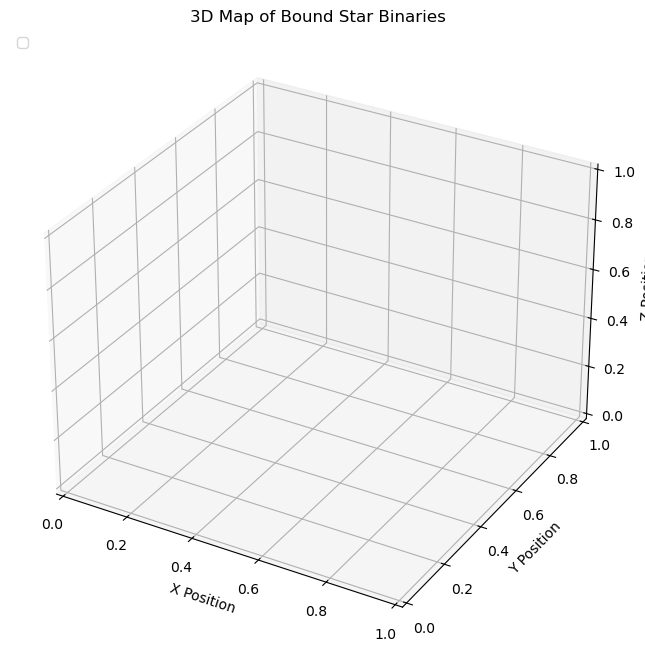

In [ ]:
#task 5? or my guess of it 

import numpy as np
import matplotlib.pyplot as plt

def process_star_file(file_path):
    with open(file_path, 'r') as f:
        delim = ',' if ',' in f.readline() else None
        
    data = np.genfromtxt(file_path, delimiter=delim, ndmin=2)
    Nstar = data.shape[0]
    
    positions = {i: (data[i, 1], data[i, 2], data[i, 3]) for i in range(Nstar)}
    pair_energies = []
    
    for i in range(Nstar):
        for j in range(i + 1, Nstar):
            m1, x1, y1, z1, vx1, vy1, vz1 = data[i, :7]
            m2, x2, y2, z2, vx2, vy2, vz2 = data[j, :7]
            
            # Calculate distance (r), vrel_sq, mu, and total energy (E)
            
            pass
            
    return pair_energies, positions


pairs1, pos1 = process_star_file('./stardata_5stars.txt')

all_pairs = pairs1 + pairs2
star_positions = {**pos1, **pos2}

#duplicate stars
pair_dict = {}
for i, j, E in all_pairs:
    key = (i, j)
    if key not in pair_dict or E < pair_dict[key]:
        pair_dict[key] = E

#isolate binairies
bound_pairs = {k: E for k, E in pair_dict.items() if E < 0}

star2_pairs = [k for k in bound_pairs.keys() if 2 in k]
if len(star2_pairs) > 1:
    best_star2 = min(star2_pairs, key=lambda k: bound_pairs[k])
    for k in star2_pairs:
        if k != best_star2:
            del bound_pairs[k]

sorted_pairs = sorted(bound_pairs.items(), key=lambda x: x[1])

#plotting
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for (i, j), E in sorted_pairs:
    print(f"Pair ({i},{j}) -> E = {E:.3e}")
    
    x1, y1, z1 = star_positions[i]
    x2, y2, z2 = star_positions[j]
    
    ax.scatter([x1, x2], [y1, y2], [z1, z2], s=100, label=f'Binary ({i},{j})')
    ax.plot3D([x1, x2], [y1, y2], [z1, z2], linestyle='-', linewidth=2)
    
    '''
    Plot the projections on XY, XZ, YZ planes and connect them with dashed lines
    '''

ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_zlabel('Z Position')
ax.set_title('3D Map of Bound Star Binaries')
ax.legend(loc='upper left')
plt.show()